# XGLUE Baseline Results Table

Loads all available XGLUE baseline outputs and renders a paper-style grouped table:
GNN baselines, other graph-based learning methods, and spectral representation baselines.
Missing future methods are kept as blank rows so the table layout stays stable.


In [5]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUTS_ROOT = Path(os.getenv("OUTPUT_BASE_DIR", PROJECT_ROOT.parent / "outputs")).resolve()
BASELINE_ROOT = OUTPUTS_ROOT / "xglue" / "baselines"
REPORT_DIR = OUTPUTS_ROOT / "xglue" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_ORDER = ["AST", "CFG", "PDG", "DDG", "CPG"]
GRAPH_ORDER_INDEX = {graph: index for index, graph in enumerate(GRAPH_ORDER)}

print("Project root:", PROJECT_ROOT)
print("Baseline root:", BASELINE_ROOT)
print("Report dir:", REPORT_DIR)


Project root: C:\Users\koush\PyProjects\spectrals\Spectral-Software
Baseline root: C:\Users\koush\PyProjects\spectrals\outputs\xglue\baselines
Report dir: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports


In [6]:
# =========================
# Result loading
# =========================
RESULT_FILES = [
    {"section": "Spectral Representations Baselines", "name": "No Train", "path": BASELINE_ROOT / "spectral" / "xglue_spectral_results.csv", "kind": "multi_graph", "display_suffix": "No Train"},
    {"section": "Spectral Representations Baselines", "name": "RF", "path": BASELINE_ROOT / "rf" / "xglue_rf_results.csv", "kind": "multi_graph", "display_suffix": "RF"},
    {"section": "Spectral Representations Baselines", "name": "LR", "path": BASELINE_ROOT / "lr" / "xglue_lr_results.csv", "kind": "multi_graph", "display_suffix": "LR"},
    {"section": "Spectral Representations Baselines", "name": "SNN", "path": REPORT_DIR / "xglue_snn_baseline_results.csv", "kind": "multi_graph", "display_suffix": "SNN"},
    {"section": "GNN Baselines", "name": "GNN", "path": REPORT_DIR / "xglue_gnn_baseline_results.csv", "kind": "multi_graph", "display_suffix": "GNN"},
    {"section": "Other Graph-based Learning Methods", "name": "Deckard", "path": REPORT_DIR / "xglue_deckard_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "RtvNN", "path": REPORT_DIR / "xglue_rtvnn_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "CDLH", "path": REPORT_DIR / "xglue_cdlh_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "DeepSim", "path": REPORT_DIR / "xglue_deepsim_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "ASTNN", "path": REPORT_DIR / "xglue_astnn_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "FA-AST+GGNN", "path": REPORT_DIR / "xglue_fa_ast_ggnn_baseline_results.csv", "kind": "single"},
    {"section": "Other Graph-based Learning Methods", "name": "FA-AST+GMN", "path": REPORT_DIR / "xglue_fa_ast_gmn_baseline_results.csv", "kind": "single"},
]


def infer_graph(row: pd.Series) -> str:
    graph = row.get("Graph", "")
    if pd.notna(graph) and str(graph).strip():
        return str(graph).strip().upper()
    method = str(row.get("Method", "")).strip().upper()
    for graph_name in GRAPH_ORDER:
        if method == graph_name or method.startswith(f"{graph_name} ") or method.startswith(f"{graph_name}+"):
            return graph_name
    return ""


def read_result(spec: dict) -> pd.DataFrame:
    path = spec["path"]
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df.columns = [str(col).strip() for col in df.columns]
    if "Method" not in df.columns and "Graph" in df.columns:
        df["Method"] = df["Graph"].astype(str)
    if "Method" not in df.columns:
        df["Method"] = spec["name"]
    if "Graph" not in df.columns:
        df["Graph"] = ""
    df["Graph"] = df.apply(infer_graph, axis=1)
    df["Section"] = spec["section"]
    df["Baseline"] = spec["name"]
    df["SourcePath"] = str(path)
    for col in ["P", "R", "F1", "Acc"]:
        if col not in df.columns:
            df[col] = pd.NA
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


raw_frames = []
missing = []
for spec in RESULT_FILES:
    df = read_result(spec)
    if df.empty:
        missing.append((spec["name"], spec["path"]))
    else:
        raw_frames.append(df)

if missing:
    print("Missing result files; blank rows will be kept for these methods:")
    for name, path in missing:
        print(f"- {name}: {path}")

raw_results = pd.concat(raw_frames, ignore_index=True) if raw_frames else pd.DataFrame()
raw_results.head()


Missing result files; blank rows will be kept for these methods:
- ASTNN: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports\xglue_astnn_baseline_results.csv
- FA-AST+GGNN: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports\xglue_fa_ast_ggnn_baseline_results.csv
- FA-AST+GMN: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports\xglue_fa_ast_gmn_baseline_results.csv


,Graph,Method,P,R,F1,Acc,Threshold,Valid_F1,Section,Baseline,SourcePath,BestEpoch,BestValidF1,TP,FP,TN,FN,TrainPairs,TestPairs,ValidPairs
0,AST,AST + No Train,0.145712,0.793207,0.246197,0.335632,0.178416,0.238382,Spectral Representations Baselines,No Train,C:\Users\koush\PyProjects\spectrals\outputs\xg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CFG,CFG + No Train,0.136901,0.999842,0.240828,0.137790,0.089921,0.229846,Spectral Representations Baselines,No Train,C:\Users\koush\PyProjects\spectrals\outputs\xg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PDG,PDG + No Train,0.141529,0.749894,0.238118,0.343639,0.135468,0.232306,Spectral Representations Baselines,No Train,C:\Users\koush\PyProjects\spectrals\outputs\xg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DDG,DDG + No Train,0.143576,0.742802,0.240639,0.358787,0.135211,0.233885,Spectral Representations Baselines,No Train,C:\Users\koush\PyProjects\spectrals\outputs\xg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CPG,CPG + No Train,0.143884,0.870891,0.246966,0.273576,0.162740,0.238483,Spectral Representations Baselines,No Train,C:\Users\koush\PyProjects\spectrals\outputs\xg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# =========================
# Paper-style row order
# =========================
def metric_lookup(baseline: str, graph: str | None = None) -> dict:
    if raw_results.empty:
        return {}
    part = raw_results[raw_results["Baseline"] == baseline]
    if graph is not None:
        part = part[part["Graph"] == graph]
    if part.empty:
        return {}
    row = part.iloc[0]
    return {col: row.get(col, pd.NA) for col in ["P", "R", "F1", "Acc"]}


rows = []

# 1) GNN Baselines: paper displays only graph names as method labels.
for graph in GRAPH_ORDER:
    rows.append({
        "Section": "GNN Baselines",
        "Method": graph,
        "Graph": graph,
        "Baseline": "GNN",
        **metric_lookup("GNN", graph),
    })

# 2) Other graph-based learning methods.
for method in ["Deckard", "RtvNN", "CDLH", "DeepSim", "ASTNN", "FA-AST+GGNN", "FA-AST+GMN"]:
    rows.append({
        "Section": "Other Graph-based Learning Methods",
        "Method": method,
        "Graph": "",
        "Baseline": method,
        **metric_lookup(method),
    })

# 3) Spectral representation baselines, grouped graph-by-graph.
for graph in GRAPH_ORDER:
    for baseline, suffix in [("No Train", "No Train"), ("RF", "RF"), ("LR", "LR"), ("SNN", "SNN")]:
        rows.append({
            "Section": "Spectral Representations Baselines",
            "Method": f"{graph} + {suffix}",
            "Graph": graph,
            "Baseline": baseline,
            **metric_lookup(baseline, graph),
        })

summary = pd.DataFrame(rows)
for col in ["P", "R", "F1", "Acc"]:
    summary[col] = pd.to_numeric(summary[col], errors="coerce")

csv_path = REPORT_DIR / "xglue_baseline_results_table.csv"
summary.to_csv(csv_path, index=False)
print("Saved:", csv_path)

table_df = summary[["Section", "Method", "P", "R", "F1", "Acc"]].copy()
for col in ["P", "R", "F1", "Acc"]:
    table_df[col] = table_df[col].map(lambda value: f"{value:.4f}" if pd.notna(value) else "")

display(table_df)


Saved: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports\xglue_baseline_results_table.csv


,Section,Method,P,R,F1,Acc
0,GNN Baselines,AST,0.2810,0.4402,0.3431,0.7694
1,GNN Baselines,CFG,0.2900,0.3704,0.3253,0.7898
2,GNN Baselines,PDG,0.3301,0.4185,0.3690,0.8043
3,GNN Baselines,DDG,0.2860,0.4448,0.3482,0.7722
4,GNN Baselines,CPG,0.4135,0.5451,0.4702,0.8320
5,Other Graph-based Learning Methods,Deckard,0.1539,0.8392,0.2601,0.3469
6,Other Graph-based Learning Methods,RtvNN,0.9567,0.8927,0.9236,0.9798
7,Other Graph-based Learning Methods,CDLH,0.9420,0.9404,0.9412,0.9839
8,Other Graph-based Learning Methods,DeepSim,0.1368,1.0000,0.2406,0.1368
9,Other Graph-based Learning Methods,ASTNN,,,,


Saved: C:\Users\koush\PyProjects\spectrals\outputs\xglue\reports\xglue_baseline_results_table.png


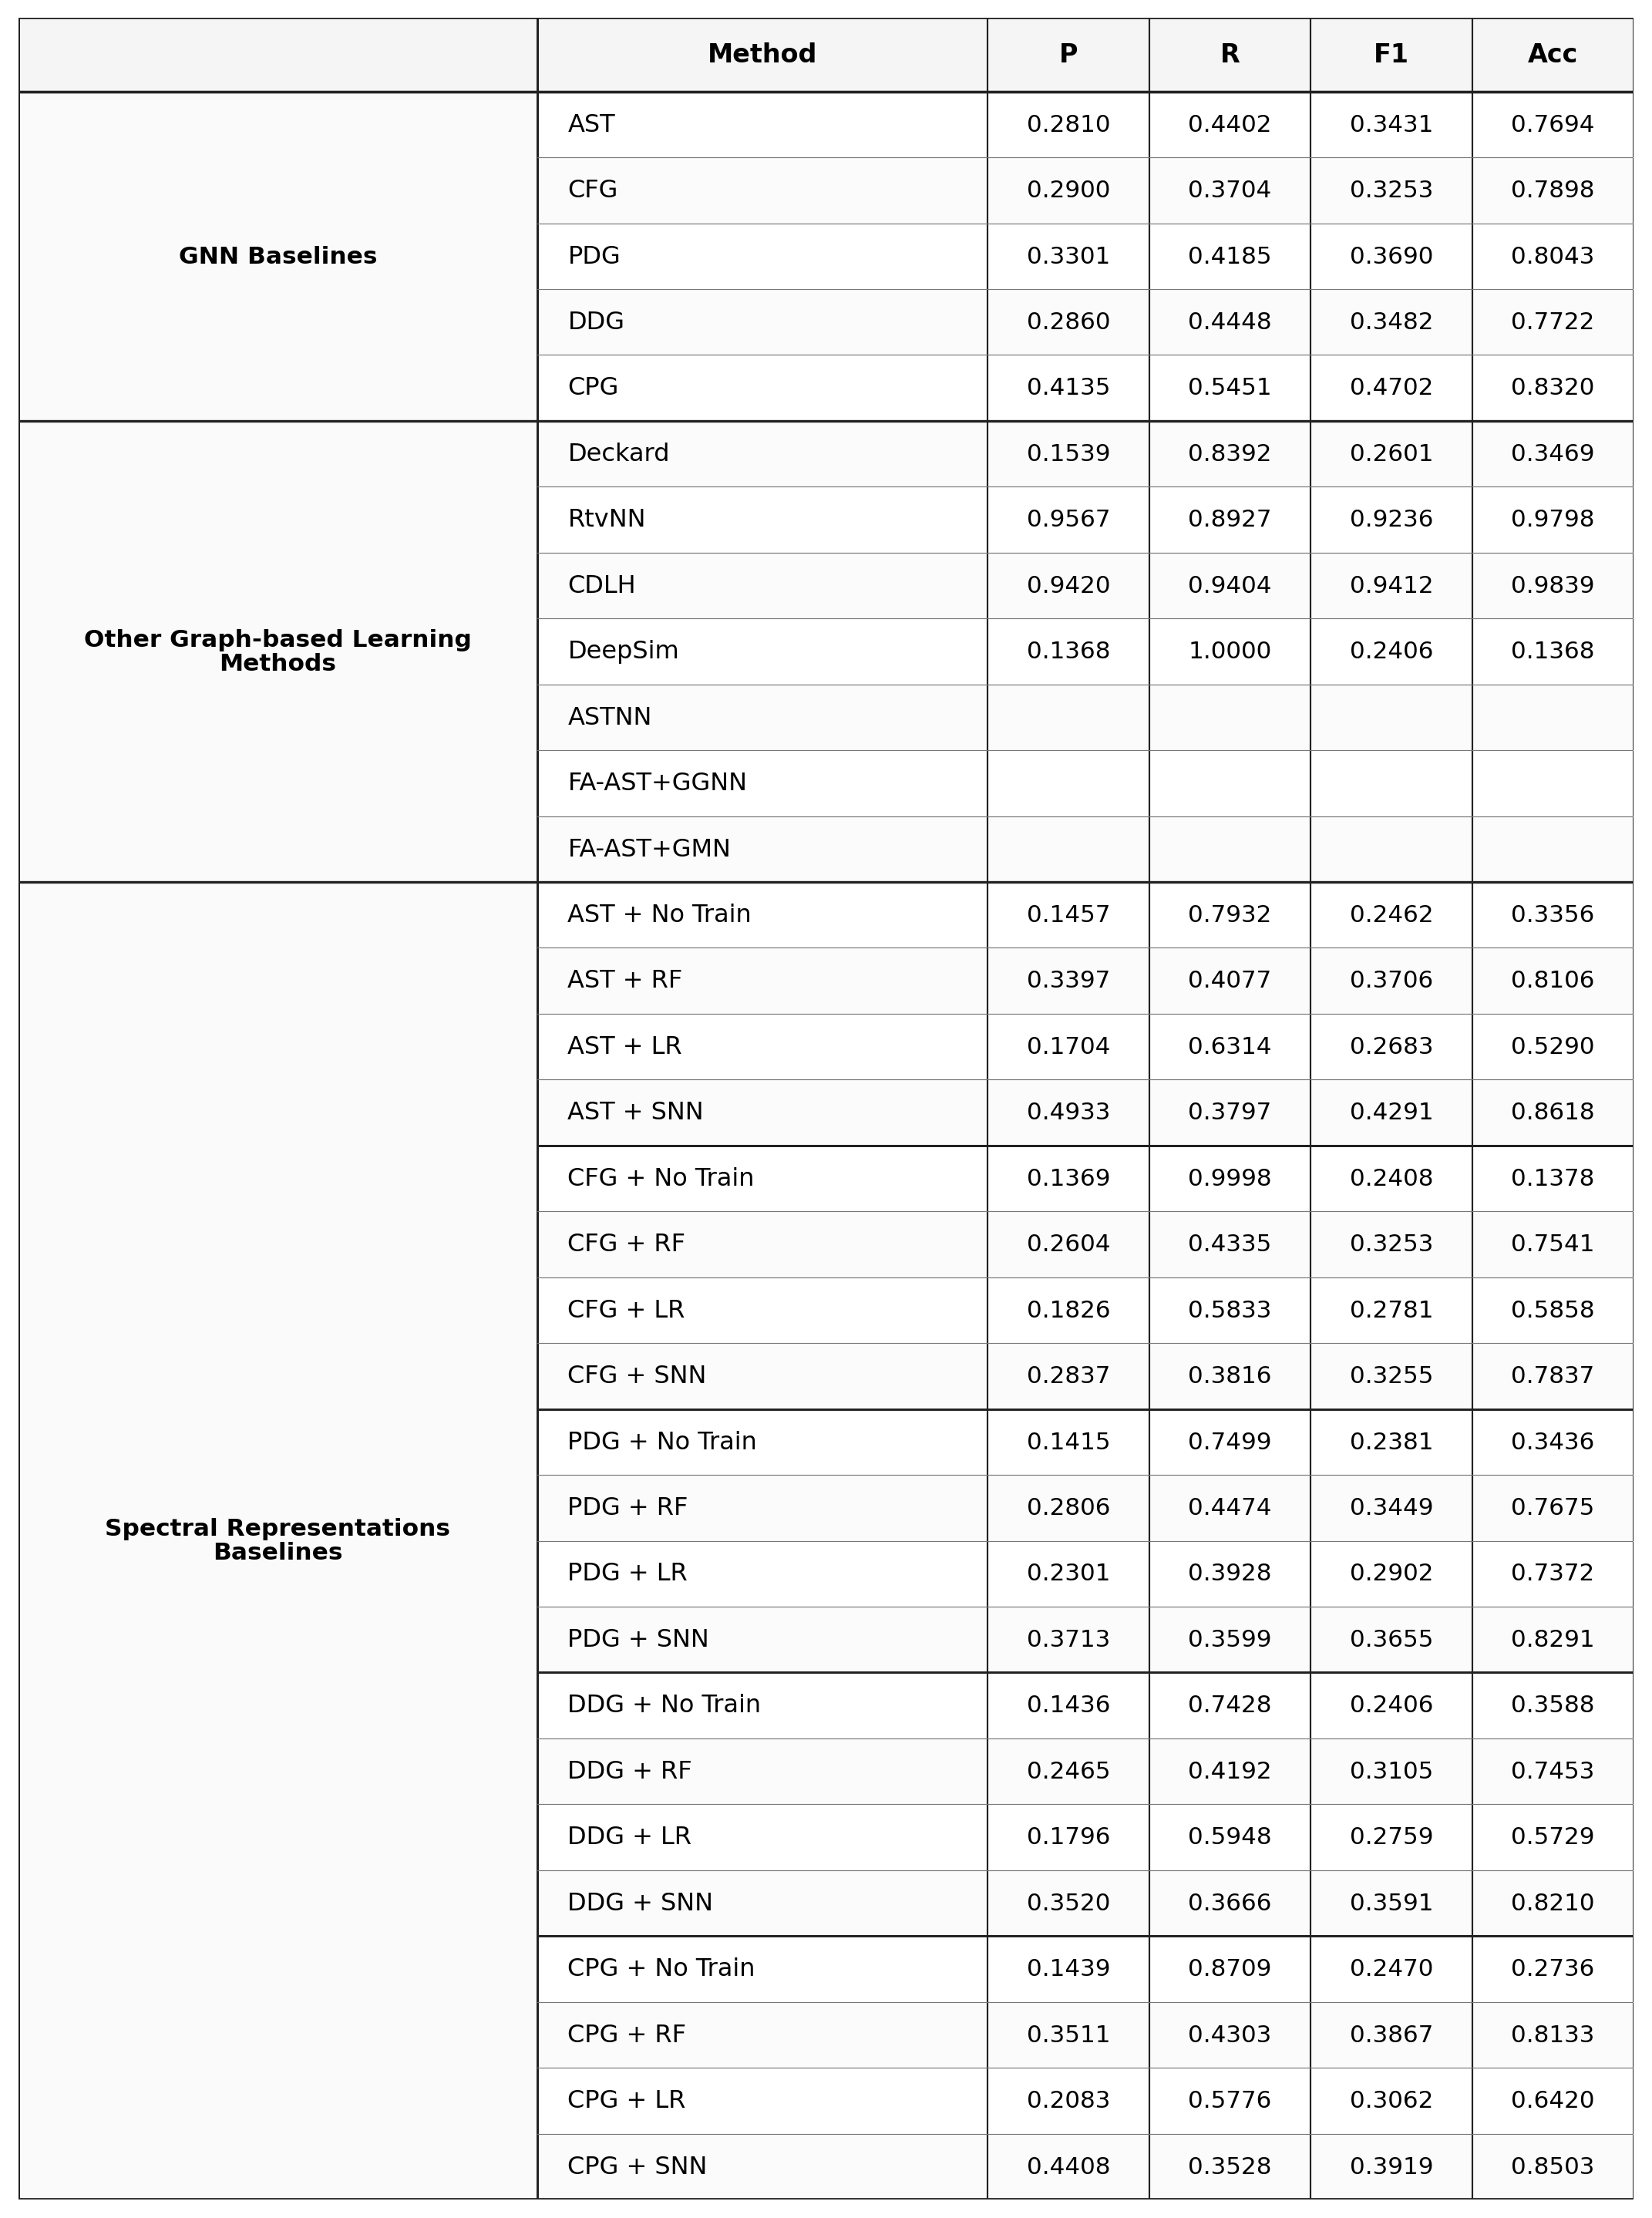

In [8]:
# =========================
# Render PNG table
# =========================
from matplotlib.patches import Rectangle
import numpy as np

plot_df = table_df[["Section", "Method", "P", "R", "F1", "Acc"]].copy()

n_rows = len(plot_df)
col_labels = ["", "Method", "P", "R", "F1", "Acc"]
col_widths = [3.05, 2.65, 0.95, 0.95, 0.95, 0.95]
x_edges = np.concatenate([[0.0], np.cumsum(col_widths)])
total_w = float(x_edges[-1])
header_h = 0.48
row_h = 0.43
total_h = header_h + n_rows * row_h

fig_h = max(8.2, 0.33 * n_rows + 1.3)
fig, ax = plt.subplots(figsize=(8.8, fig_h))
ax.set_xlim(0, total_w)
ax.set_ylim(total_h, 0)
ax.axis("off")

line_color = "#222222"
minor_color = "#777777"
header_face = "#f5f5f5"
section_face = "#fafafa"

# Header background and labels.
for col, label in enumerate(col_labels):
    x0, x1 = x_edges[col], x_edges[col + 1]
    ax.add_patch(Rectangle((x0, 0), x1 - x0, header_h, facecolor=header_face, edgecolor="none"))
    ax.text((x0 + x1) / 2, header_h / 2, label, ha="center", va="center", fontsize=10, fontweight="bold")

# Alternating row background outside the merged section column.
for i in range(n_rows):
    y0 = header_h + i * row_h
    face = "#ffffff" if i % 2 == 0 else "#fbfbfb"
    ax.add_patch(Rectangle((x_edges[1], y0), total_w - x_edges[1], row_h, facecolor=face, edgecolor="none"))

# Merged section cells.
section_spans = []
for section, indexes in summary.groupby("Section", sort=False).groups.items():
    idxs = list(indexes)
    start, end = min(idxs), max(idxs) + 1
    section_spans.append((section, start, end))
    y0 = header_h + start * row_h
    height = (end - start) * row_h
    ax.add_patch(Rectangle((0, y0), x_edges[1], height, facecolor=section_face, edgecolor="none"))
    label = section.replace(" Learning ", " Learning\n").replace(" Representations ", " Representations\n")
    ax.text(
        x_edges[1] / 2,
        y0 + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=9.4,
        fontweight="bold",
        linespacing=1.08,
    )

# Data text.
for i, row in plot_df.iterrows():
    y = header_h + i * row_h + row_h / 2
    ax.text(x_edges[1] + 0.18, y, str(row["Method"]), ha="left", va="center", fontsize=9.6)
    for j, col in enumerate(["P", "R", "F1", "Acc"], start=2):
        ax.text((x_edges[j] + x_edges[j + 1]) / 2, y, str(row[col]), ha="center", va="center", fontsize=9.3)

# Vertical rules.
for x in x_edges:
    ax.plot([x, x], [0, total_h], color=line_color, linewidth=0.9 if x in [x_edges[0], x_edges[-1], x_edges[1]] else 0.65)

# Outer/header rules.
ax.plot([0, total_w], [0, 0], color=line_color, linewidth=1.1)
ax.plot([0, total_w], [header_h, header_h], color=line_color, linewidth=1.0)
ax.plot([0, total_w], [total_h, total_h], color=line_color, linewidth=1.1)

# Light row rules from Method onward only, so group labels are never crossed.
for i in range(1, n_rows):
    y = header_h + i * row_h
    ax.plot([x_edges[1], total_w], [y, y], color=minor_color, linewidth=0.35)

# Major section boundaries across the full table.
major_boundaries = sorted({0, n_rows} | {start for _, start, _ in section_spans} | {end for _, _, end in section_spans})
for idx in major_boundaries:
    y = header_h + idx * row_h
    ax.plot([0, total_w], [y, y], color=line_color, linewidth=1.0)

# Spectral graph sub-block separators, again only from Method onward.
spectral_start = int(summary.index[summary["Section"] == "Spectral Representations Baselines"].min())
for offset in [4, 8, 12, 16]:
    y = header_h + (spectral_start + offset) * row_h
    ax.plot([x_edges[1], total_w], [y, y], color=line_color, linewidth=0.9)

fig.tight_layout(pad=0.25)
png_path = REPORT_DIR / "xglue_baseline_results_table.png"
fig.savefig(png_path, dpi=240, bbox_inches="tight", facecolor="white")
plt.close(fig)
print("Saved:", png_path)
display(Image(filename=str(png_path)))
